# Kalp Hastalığı Tahmini

Bu notebook üç bölümden oluşur: veri önişleme, sınıflandırma modelleri (Random Forest ve Gradient Boosting) ve Tree Augmented Naive Bayes (TAN) ile Bayes ağı modeli.

## 1. Veri Önişleme

In [1]:
import os
import warnings
os.environ['TQDM_DISABLE'] = '1'  # pgmpy tahmin sırasında ilerleme çubuğu basmasın
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import networkx as nx
from scipy import stats

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report)

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import TreeSearch
from pgmpy.global_vars import config as pgmpy_config
import logging

# pgmpy'nin bilgi mesajları kapatılır
logging.getLogger('pgmpy').setLevel(logging.WARNING)
pgmpy_config.set_show_progress(False)

df = pd.read_csv('heart.csv')

print("Veri setinin ilk hali:")
display(df.head())

Veri setinin ilk hali:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
# Kolesterol değeri 0 olan kayıtlar ölçüm eksikliği olarak kabul edilir
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

# Doldurma öncesi doluluk durumu
doluluk_oranlari = df.count() / len(df) * 100
doluluk_tablosu = pd.DataFrame({
    'Toplam Veri': len(df),
    'Dolu Veri': df.count(),
    'Eksik Veri': df.isna().sum(),
    'Doluluk Oranı (%)': doluluk_oranlari
})
print("Doldurma öncesi veri seti durumu:")
print(doluluk_tablosu.sort_values(by='Doluluk Oranı (%)', ascending=False))

# Eksik kolesterol değerleri ortalama ile doldurulur
cholesterol_mean = df['Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].fillna(cholesterol_mean)
print(f"\nCholesterol sütunundaki eksik veriler ortalama ({cholesterol_mean:.2f}) ile dolduruldu.")

Doldurma öncesi veri seti durumu:
                Toplam Veri  Dolu Veri  Eksik Veri  Doluluk Oranı (%)
Age                     918        918           0         100.000000
Sex                     918        918           0         100.000000
ChestPainType           918        918           0         100.000000
RestingBP               918        918           0         100.000000
FastingBS               918        918           0         100.000000
RestingECG              918        918           0         100.000000
MaxHR                   918        918           0         100.000000
ExerciseAngina          918        918           0         100.000000
ST_Slope                918        918           0         100.000000
Oldpeak                 918        918           0         100.000000
HeartDisease            918        918           0         100.000000
Cholesterol             918        746         172          81.263617

Cholesterol sütunundaki eksik veriler ortalama (244.64)

In [3]:
# Aykırı değer temizliği (Z-Score > 3)
numerical_cols = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Age']
z_scores = np.abs(stats.zscore(df[numerical_cols]))
outlier_indices = (z_scores > 3).any(axis=1)

print(f"Toplam aykırı değer sayısı: {outlier_indices.sum()}")

df_cleaned = df[~outlier_indices].copy()
print(f"Temizlik sonrası satır sayısı: {df_cleaned.shape[0]}")

Toplam aykırı değer sayısı: 28
Temizlik sonrası satır sayısı: 890


In [4]:
# Kategorik verilerin sayısala dönüştürülmesi (Label Encoding)
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le = LabelEncoder()
for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

display(df_cleaned[categorical_cols].head())

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,1,1,1,0,2
1,0,2,1,0,1
2,1,1,2,0,2
3,0,0,1,1,1
4,1,2,1,0,2


In [5]:
# Min-Max normalizasyonu
scaler = MinMaxScaler()
cols_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

display(df_cleaned.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.244898,1,1,0.571429,0.639498,0,1,0.784173,0,0.333333,2,0
1,0.428571,0,2,0.761905,0.297806,0,1,0.669065,0,0.500000,1,1
2,0.183673,1,1,0.476190,0.620690,0,2,0.251799,0,0.333333,2,0
3,0.408163,0,0,0.552381,0.404389,0,1,0.323741,1,0.583333,1,1
4,0.530612,1,2,0.666667,0.344828,0,1,0.424460,0,0.333333,2,0


In [6]:
# Yeni nitelik: yaş kategorisi (0: genç, 1: orta yaş, 2: yaşlı)
bins = [0, 40, 60, 100]
labels = [0, 1, 2]

original_ages = df.loc[df_cleaned.index, 'Age']
df_cleaned['Age_Category'] = pd.cut(original_ages, bins=bins, labels=labels).astype(int)

display(df_cleaned[['Age', 'Age_Category']].head())

,Age,Age_Category
0,0.244898,0
1,0.428571,1
2,0.183673,0
3,0.408163,1
4,0.530612,1


In [7]:
df_cleaned.info()
df_cleaned.to_csv('heart_onislenmis.csv', index=False)
print("Önişlenmiş veri kaydedildi: heart_onislenmis.csv")

<class 'pandas.core.frame.DataFrame'>
Index: 890 entries, 0 to 917
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             890 non-null    float64
 1   Sex             890 non-null    int64  
 2   ChestPainType   890 non-null    int64  
 3   RestingBP       890 non-null    float64
 4   Cholesterol     890 non-null    float64
 5   FastingBS       890 non-null    int64  
 6   RestingECG      890 non-null    int64  
 7   MaxHR           890 non-null    float64
 8   ExerciseAngina  890 non-null    int64  
 9   Oldpeak         890 non-null    float64
 10  ST_Slope        890 non-null    int64  
 11  HeartDisease    890 non-null    int64  
 12  Age_Category    890 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 97.3 KB
Önişlenmiş veri kaydedildi: heart_onislenmis.csv


## 2. Random Forest

In [8]:
X = df_cleaned.drop('HeartDisease', axis=1)
y = df_cleaned['HeartDisease']

# Verinin %10'u final testi için ayrılır, kalan %90 eğitim (%80) ve test (%20) olarak bölünür
X_temp, X_holdout, y_temp, y_holdout = train_test_split(X, y, test_size=0.10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.20, random_state=42)

print(f"Toplam: {len(X)} | Holdout: {len(X_holdout)} | Eğitim: {len(X_train)} | Test: {len(X_test)}")

Toplam: 890 | Holdout: 89 | Eğitim: 640 | Test: 161


In [9]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print(f"Çapraz doğrulama skorları: {np.round(cv_scores, 4)}")
print(f"Ortalama doğruluk: {cv_scores.mean():.4f}")

Çapraz doğrulama skorları: [0.8828 0.8047 0.875  0.875  0.8906]
Ortalama doğruluk: 0.8656


Test seti doğruluğu: 0.8385

              precision    recall  f1-score   support

           0       0.83      0.80      0.81        71
           1       0.85      0.87      0.86        90

    accuracy                           0.84       161
   macro avg       0.84      0.83      0.84       161
weighted avg       0.84      0.84      0.84       161



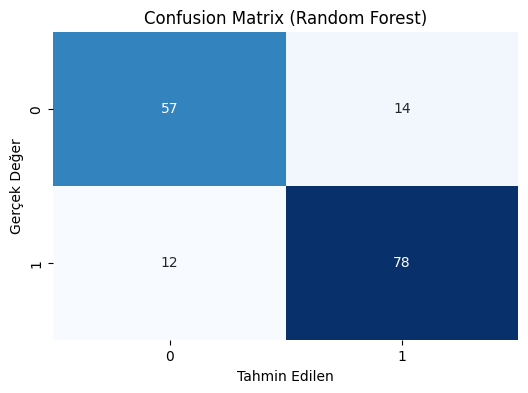

In [10]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test seti doğruluğu: {acc:.4f}\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

In [11]:
y_holdout_pred = rf_model.predict(X_holdout)
acc_holdout = accuracy_score(y_holdout, y_holdout_pred)
print(f"Holdout seti doğruluğu: {acc_holdout:.4f}\n")
print(classification_report(y_holdout, y_holdout_pred))

Holdout seti doğruluğu: 0.9438

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        40
           1       0.96      0.94      0.95        49

    accuracy                           0.94        89
   macro avg       0.94      0.94      0.94        89
weighted avg       0.94      0.94      0.94        89



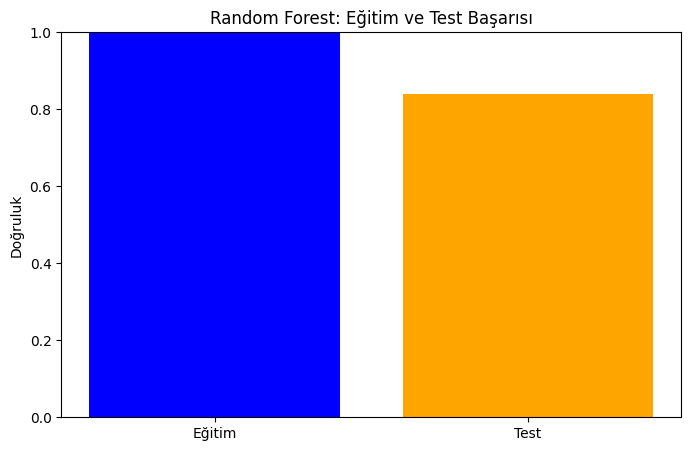

In [12]:
train_acc = accuracy_score(y_train, rf_model.predict(X_train))

plt.figure(figsize=(8, 5))
plt.bar(['Eğitim', 'Test'], [train_acc, acc], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.title('Random Forest: Eğitim ve Test Başarısı')
plt.ylabel('Doğruluk')
plt.show()

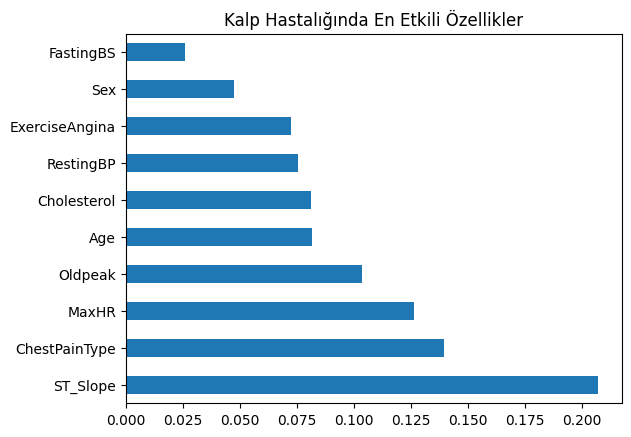

In [13]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Kalp Hastalığında En Etkili Özellikler")
plt.show()

## 3. Gradient Boosting

In [14]:
veri = pd.read_csv("heart_onislenmis.csv")
X = veri.drop('HeartDisease', axis=1)
y = veri['HeartDisease']

X_gecici, X_sakli, y_gecici, y_sakli = train_test_split(X, y, test_size=0.10, random_state=42)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_gecici, y_gecici, test_size=0.20, random_state=42)

print(f"Eğitim: {len(X_egitim)} | Test: {len(X_test)} | Saklı: {len(X_sakli)}")

Eğitim: 640 | Test: 161 | Saklı: 89


In [15]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

capraz_dogrulama_skorlari = cross_val_score(model, X_egitim, y_egitim, cv=5)
print(f"Çapraz doğrulama skorları: {', '.join(f'{s:.2f}' for s in capraz_dogrulama_skorlari)}")
print(f"Ortalama: {capraz_dogrulama_skorlari.mean():.2f}")

Çapraz doğrulama skorları: 0.88, 0.84, 0.90, 0.88, 0.85
Ortalama: 0.87


In [16]:
model.fit(X_egitim, y_egitim)
y_tahmin = model.predict(X_test)

dogruluk_orani = accuracy_score(y_test, y_tahmin)
print(f"Test seti doğruluğu: {dogruluk_orani:.2f}\n")
print(classification_report(y_test, y_tahmin))

Test seti doğruluğu: 0.84

              precision    recall  f1-score   support

           0       0.83      0.80      0.81        71
           1       0.85      0.87      0.86        90

    accuracy                           0.84       161
   macro avg       0.84      0.83      0.84       161
weighted avg       0.84      0.84      0.84       161



In [17]:
joblib.dump(model, "kalp_modeli_gb.pkl")
print("Model kaydedildi: kalp_modeli_gb.pkl")

Model kaydedildi: kalp_modeli_gb.pkl


In [18]:
# Kaydedilen model yüklenir ve daha önce hiç kullanılmamış saklı veri üzerinde test edilir
yuklenen_model = joblib.load("kalp_modeli_gb.pkl")
yeni_tahminler = yuklenen_model.predict(X_sakli)

sonuc_tablosu = X_sakli.copy()
sonuc_tablosu["Gercek_Durum"] = y_sakli
sonuc_tablosu["Modelin_Tahmini"] = yeni_tahminler
display(sonuc_tablosu.head())

final_basarisi = accuracy_score(y_sakli, yeni_tahminler)
print(f"Saklı veri doğruluğu: {final_basarisi:.2f}")

sonuc_tablosu.to_csv("tahmin_sonuclari.csv", index=False)
print("Tahmin sonuçları kaydedildi: tahmin_sonuclari.csv")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Age_Category,Gercek_Durum,Modelin_Tahmini
280,0.408163,1,2,0.285714,0.394984,0,1,0.539568,0,0.333333,2,1,0,0
434,0.714286,1,0,0.761905,0.454545,1,1,0.302158,1,0.500000,1,2,1,1
39,0.530612,0,2,0.476190,0.655172,0,2,0.266187,1,0.333333,1,1,1,0
417,0.693878,1,0,0.380952,0.423197,0,2,0.165468,0,0.333333,2,2,0,0
585,0.673469,1,2,0.380952,0.789969,0,1,0.251799,1,0.333333,1,2,1,1


Saklı veri doğruluğu: 0.91
Tahmin sonuçları kaydedildi: tahmin_sonuclari.csv


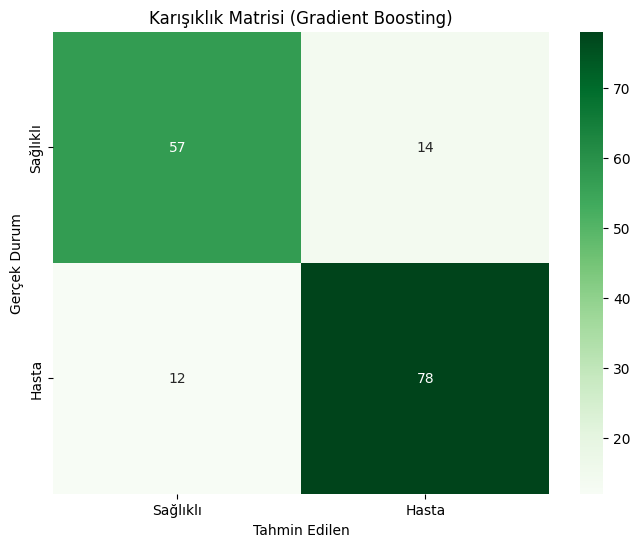

In [19]:
karmasiklik_matrisi = confusion_matrix(y_test, y_tahmin)
plt.figure(figsize=(8, 6))
sns.heatmap(karmasiklik_matrisi, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Sağlıklı", "Hasta"], yticklabels=["Sağlıklı", "Hasta"])
plt.title("Karışıklık Matrisi (Gradient Boosting)")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Durum")
plt.show()

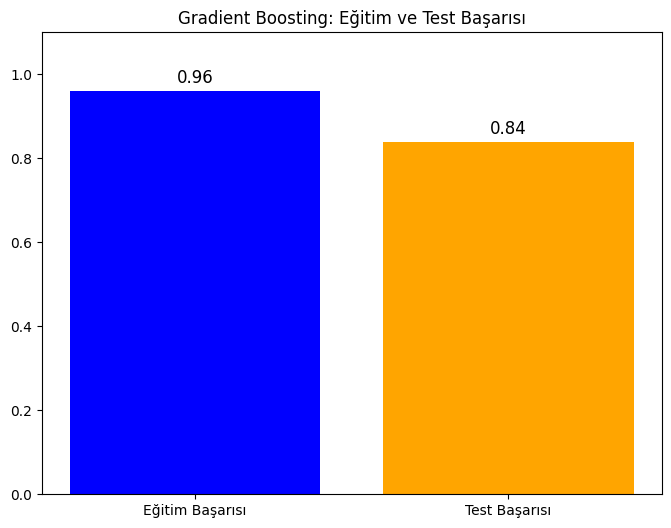

In [20]:
egitim_basarisi = accuracy_score(y_egitim, model.predict(X_egitim))
test_basarisi = accuracy_score(y_test, y_tahmin)

plt.figure(figsize=(8, 6))
cubuklar = plt.bar(["Eğitim Başarısı", "Test Başarısı"],
                   [egitim_basarisi, test_basarisi], color=['blue', 'orange'])
for cubuk in cubuklar:
    plt.text(cubuk.get_x() + cubuk.get_width() / 2, cubuk.get_height() + 0.01,
             round(cubuk.get_height(), 2), ha='center', va='bottom', fontsize=12)
plt.ylim(0, 1.1)
plt.title("Gradient Boosting: Eğitim ve Test Başarısı")
plt.show()

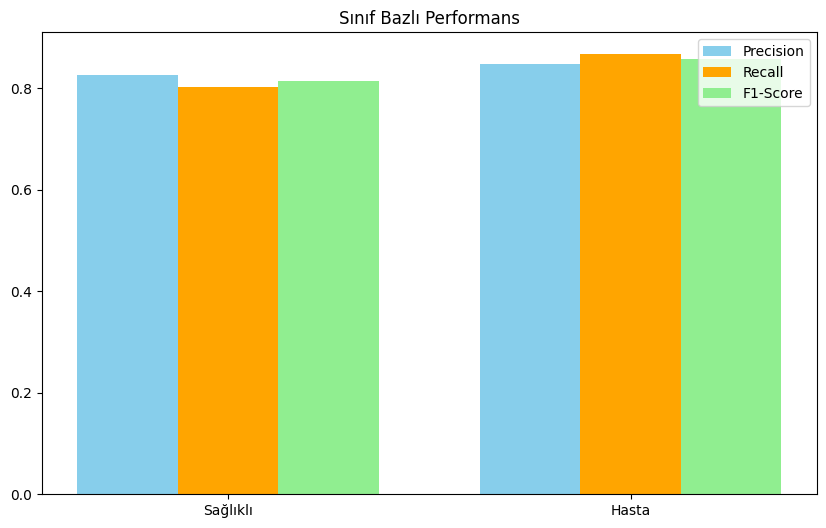

In [21]:
rapor = classification_report(y_test, y_tahmin, output_dict=True)
siniflar = ['0', '1']
kesinlik = [rapor[c]["precision"] for c in siniflar]
duyarlilik = [rapor[c]["recall"] for c in siniflar]
f1_skorlari = [rapor[c]["f1-score"] for c in siniflar]

x = np.arange(len(siniflar))
plt.figure(figsize=(10, 6))
plt.bar(x - 0.25, kesinlik, 0.25, label="Precision", color='skyblue')
plt.bar(x, duyarlilik, 0.25, label="Recall", color='orange')
plt.bar(x + 0.25, f1_skorlari, 0.25, label="F1-Score", color='lightgreen')
plt.xticks(x, ["Sağlıklı", "Hasta"])
plt.legend()
plt.title("Sınıf Bazlı Performans")
plt.show()

## 4. Bayes Ağı (Tree Augmented Naive Bayes)

In [22]:
target_col = 'HeartDisease'

df = pd.read_csv('heart_onislenmis.csv')
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
test_data_full = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

print(f"Eğitim: {len(train_data)} | Test: {len(test_data_full)}")

Eğitim: 712 | Test: 178


In [23]:
# Sürekli değişkenler 5 aralığa bölünür. Aralık sınırları sadece eğitim verisinden
# hesaplanır ve test verisine aynı sınırlar uygulanır.
continuous_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in continuous_cols:
    train_data[col], sinirlar = pd.cut(train_data[col], bins=5, labels=False, retbins=True)
    sinirlar[0], sinirlar[-1] = -np.inf, np.inf
    test_data_full[col] = pd.cut(test_data_full[col], bins=sinirlar, labels=False)

train_data = train_data.astype(str)
test_data_full = test_data_full.astype(str)

display(train_data.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Age_Category,HeartDisease
0,1,1,1,1,3,0,1,3,0,1,2,1,0
1,1,1,0,2,2,0,2,2,1,2,1,1,1
2,2,1,0,3,2,1,1,1,1,3,1,1,1
3,2,1,0,2,3,0,1,4,1,2,2,1,1
4,1,0,2,0,1,0,1,4,0,1,2,0,0


In [24]:
# TAN yapısının öğrenilmesi ve olasılık tablolarının (CPT) hesaplanması
est = TreeSearch(train_data)
dag = est.estimate(estimator_type='tan', class_node=target_col, show_progress=False)
print(f"Toplam bağlantı sayısı: {len(dag.edges())}")

bn_model = DiscreteBayesianNetwork(dag.edges())
bn_model.fit(train_data)  # varsayılan: Maximum Likelihood
print("Model eğitildi.")

Toplam bağlantı sayısı: 23
Model eğitildi.


In [25]:
predict_data = test_data_full.drop(target_col, axis=1)
y_pred_bn = bn_model.predict(predict_data, n_jobs=1)

y_true = test_data_full[target_col]
print(f"Accuracy : {accuracy_score(y_true, y_pred_bn[target_col]):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred_bn[target_col], average='weighted'):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_bn[target_col], average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred_bn[target_col], average='weighted'):.4f}")

Accuracy : 0.8708
F1 Score : 0.8707
Precision: 0.8707
Recall   : 0.8708


In [26]:
# Her değişken, geri kalan değişkenler kullanılarak tahmin edilir
accuracy_dict = {}

for column in test_data_full.columns:
    temp_pred_data = test_data_full.drop(column, axis=1)
    y_pred_temp = bn_model.predict(temp_pred_data, n_jobs=1)
    accuracy_dict[column] = accuracy_score(test_data_full[column], y_pred_temp[column])
    print(f"{column: <15} | Doğruluk: {accuracy_dict[column]:.4f}")

avg_acc = sum(accuracy_dict.values()) / len(accuracy_dict)
print("-" * 40)
print(f"Tüm değişkenlerin ortalama doğruluğu: {avg_acc:.4f}")

Age             | Doğruluk: 0.5730


Sex             | Doğruluk: 0.7978


ChestPainType   | Doğruluk: 0.5281


RestingBP       | Doğruluk: 0.4607


Cholesterol     | Doğruluk: 0.5674


...

ExerciseAngina  | Doğruluk: 0.7809


Oldpeak         | Doğruluk: 0.5787


ST_Slope        | Doğruluk: 0.7640


Age_Category    | Doğruluk: 0.8371


HeartDisease    | Doğruluk: 0.8708
----------------------------------------
Tüm değişkenlerin ortalama doğruluğu: 0.6577


In [27]:
# İlk üç değişkenin koşullu olasılık tablosu
for cpd in bn_model.get_cpds()[:3]:
    print(f"\nDeğişken: {cpd.variable} | Ebeveynler: {cpd.variables[1:]}")
    print(f"Tablo boyutu: {cpd.values.shape}")
    print(np.round(cpd.values, 3))


Değişken: Age | Ebeveynler: ['HeartDisease']
Tablo boyutu: (5, 2)
[[0.075 0.026]
 [0.293 0.143]
 [0.408 0.366]
 [0.187 0.389]
 [0.037 0.077]]

Değişken: Age_Category | Ebeveynler: ['Age', 'HeartDisease']
Tablo boyutu: (3, 5, 2)
[[[1.    1.   ]
  [0.223 0.25 ]
  [0.    0.   ]
  [0.    0.   ]
  [0.    0.   ]]

 [[0.    0.   ]
  [0.777 0.75 ]
  [1.    1.   ]
  [0.467 0.368]
  [0.    0.   ]]

 [[0.    0.   ]
  [0.    0.   ]
  [0.    0.   ]
  [0.533 0.632]
  [1.    1.   ]]]

Değişken: MaxHR | Ebeveynler: ['Age', 'HeartDisease']
Tablo boyutu: (5, 5, 2)
[[[0.    0.   ]
  [0.011 0.   ]
  [0.    0.035]
  [0.    0.079]
  [0.    0.033]]

 [[0.042 0.   ]
  [0.032 0.143]
  [0.107 0.294]
  [0.1   0.276]
  [0.167 0.467]]

 [[0.    0.6  ]
  [0.213 0.464]
  [0.321 0.42 ]
  [0.433 0.401]
  [0.5   0.367]]

 [[0.375 0.3  ]
  [0.394 0.286]
  [0.389 0.21 ]
  [0.4   0.204]
  [0.333 0.133]]

 [[0.583 0.1  ]
  [0.351 0.107]
  [0.183 0.042]
  [0.067 0.039]
  [0.    0.   ]]]


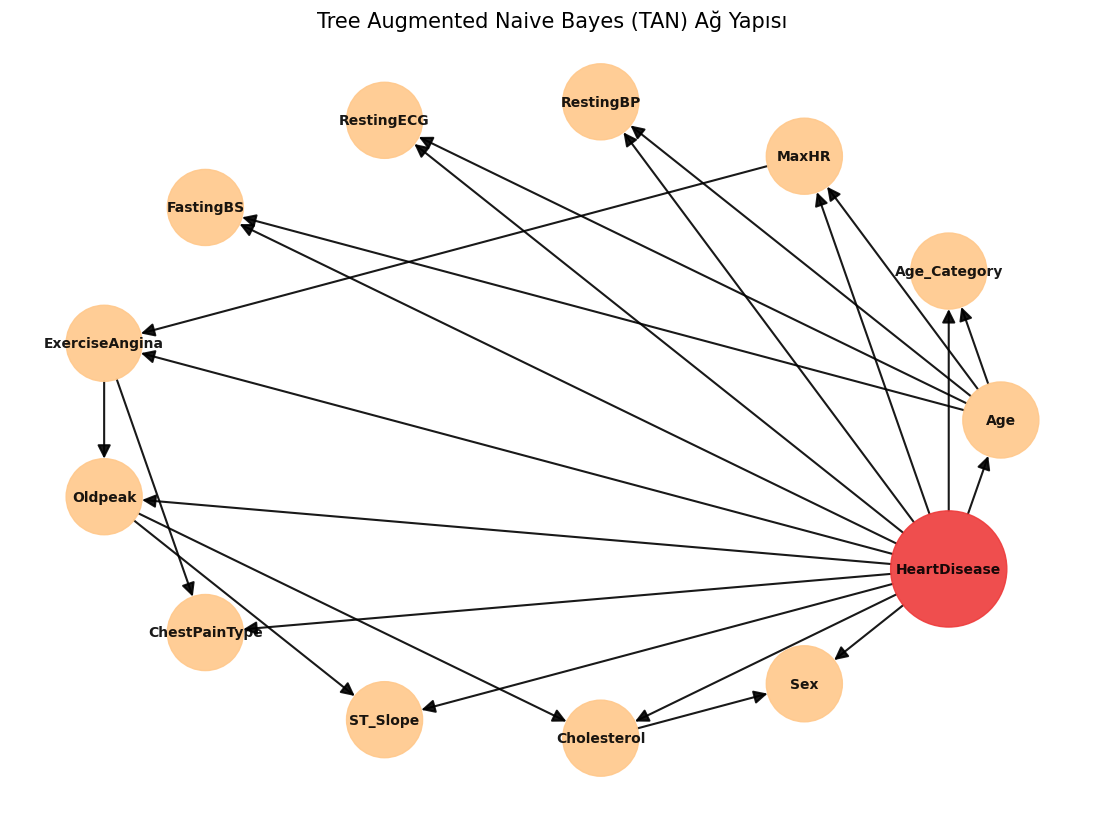

In [28]:
G = nx.DiGraph()
G.add_edges_from(bn_model.edges())
all_nodes = list(G.nodes())

node_colors = ['#EE3B3B' if node == target_col else '#FFC88B' for node in all_nodes]
node_sizes = [7000 if node == target_col else 3000 for node in all_nodes]
pos = nx.circular_layout(G)

plt.figure(figsize=(14, 10))
nx.draw_networkx(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes,
                 font_size=10, font_weight="bold", arrowsize=20, width=1.5, alpha=0.9)
plt.title("Tree Augmented Naive Bayes (TAN) Ağ Yapısı", fontsize=15)
plt.axis('off')
plt.savefig('HeartDisease_TAN_Network.pdf', format='pdf', bbox_inches='tight')
plt.show()